In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from config import *

from lisaorbits import KeplerianOrbits, StaticConstellation
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

## Gravitational Waves

In [27]:
with h5py.File(gw_ehm_dataset_path, "r") as h5:
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]
    qt_array = h5["QT"][:]
    t_qscan_array = h5["t_qscan"][:]
    f_qscan_array = h5["f_qscan"][:]

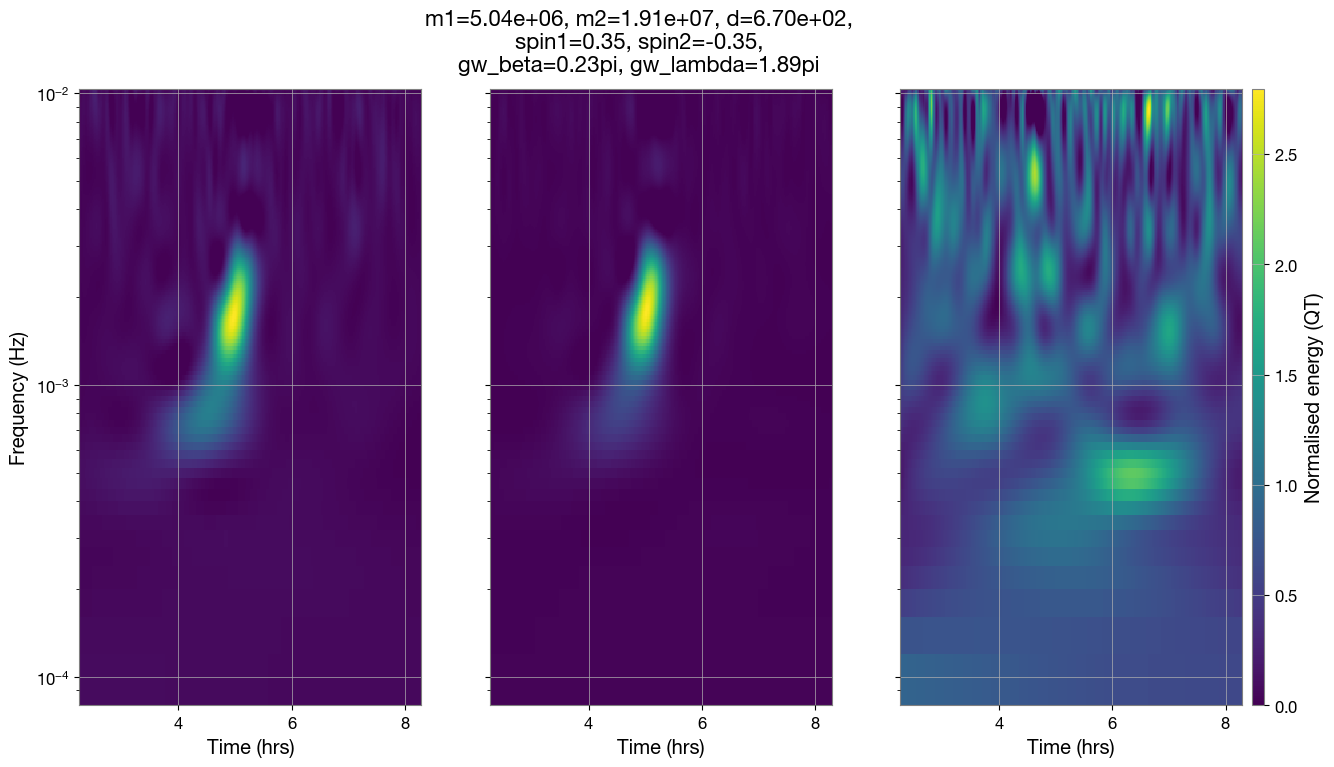

In [30]:
index = 186  # Change this index to visualize different samples
m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]
QT = qt_array[index]
t_qscan = t_qscan_array[index]
f_qscan = f_qscan_array[index]

QT_A = QT[:, :, 0]
QT_E = QT[:, :, 1]
QT_T = QT[:, :, 2]

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15,8))
title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, \n' +\
    f'spin1={spin1:.2f}, spin2={spin2:.2f}, \n' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi \n'
fig.suptitle(title, fontsize=16)
    
axes[0].pcolormesh(t_qscan/3600, f_qscan, QT_A, cmap='viridis')
axes[1].pcolormesh(t_qscan/3600, f_qscan, QT_E, cmap='viridis')
axes[2].pcolormesh(t_qscan/3600, f_qscan, QT_T, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[2].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[2].colorbar(label='Normalised energy (QT)')
plt.show()

## Glitches

In [13]:
with h5py.File(glitch_ehm_dataset_path, "r") as h5:
    level_array = h5["level"][:]
    beta_array = h5["beta"][:]
    inj_point_array = h5["inj_point"][:]
    qt_array = h5["QT"][:]
    t_qscan_array = h5["t_qscan"][:]
    f_qscan_array = h5["f_qscan"][:]

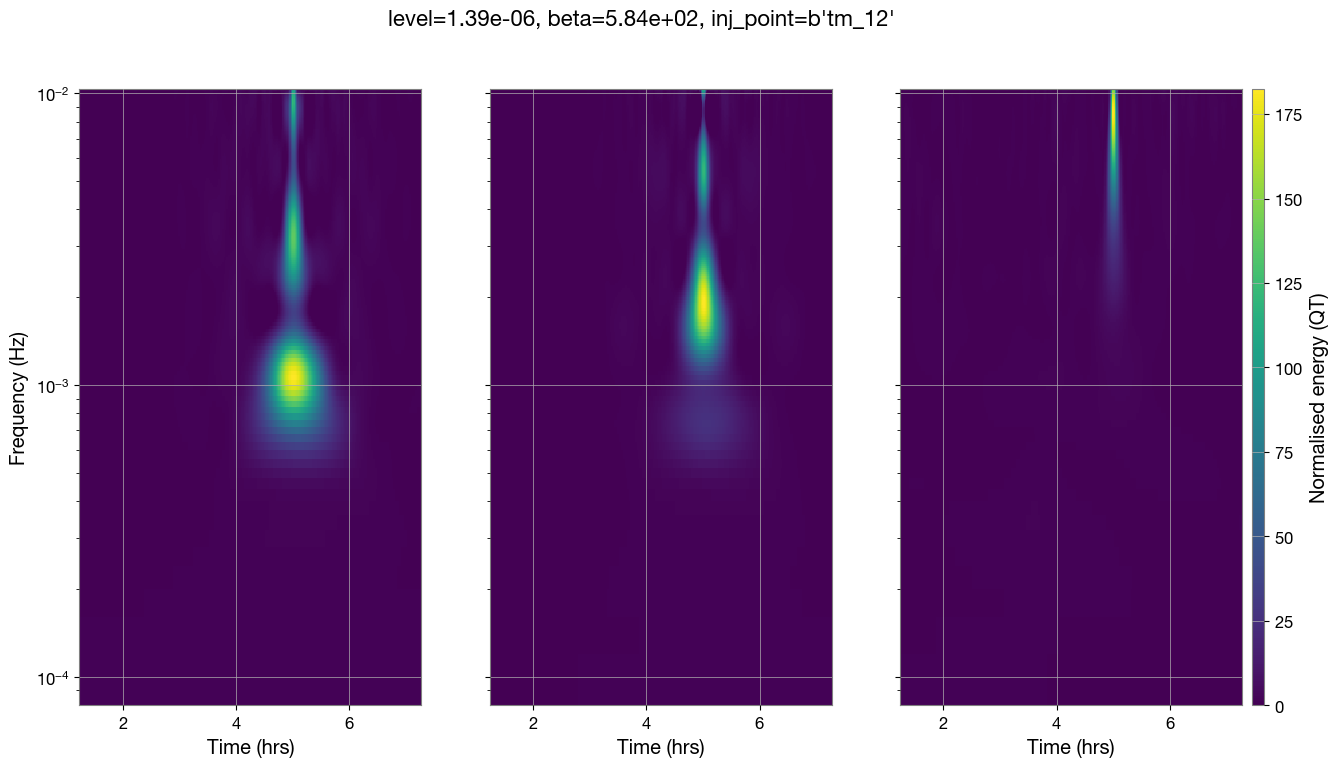

In [15]:
index = 270  # Change this index to visualize different samples
level = level_array[index]
beta = beta_array[index]
inj_point = inj_point_array[index]
QT = qt_array[index]
t_qscan = t_qscan_array[index]
f_qscan = f_qscan_array[index]

QT_A = QT[:, :, 0]
QT_E = QT[:, :, 1]
QT_T = QT[:, :, 2]

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15,8))
title = f'level={level:.2e}, beta={beta:.2e}, inj_point={inj_point}'
fig.suptitle(title, fontsize=16)
    
axes[0].pcolormesh(t_qscan/3600, f_qscan, QT_A, cmap='viridis')
axes[1].pcolormesh(t_qscan/3600, f_qscan, QT_E, cmap='viridis')
axes[2].pcolormesh(t_qscan/3600, f_qscan, QT_T, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[2].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[2].colorbar(label='Normalised energy (QT)')
plt.show()

## GW + Glitch

In [40]:
with h5py.File(mixed_lm_dataset_path, "r") as h5:
    m1_array = h5["m1"][:]
    m2_array = h5["m2"][:]
    d_array = h5["d"][:]
    spin1_array = h5["spin1"][:]
    spin2_array = h5["spin2"][:]
    gw_beta_array = h5["gw_beta"][:]
    gw_lambda_array = h5["gw_lambda"][:]
    level_array = h5["level"][:]
    beta_array = h5["beta"][:]
    inj_point_array = h5["inj_point"][:]
    sep_array = h5["sep"][:]
    qt_array = h5["QT"][:]
    t_qscan_array = h5["t_qscan"][:]
    f_qscan_array = h5["f_qscan"][:]

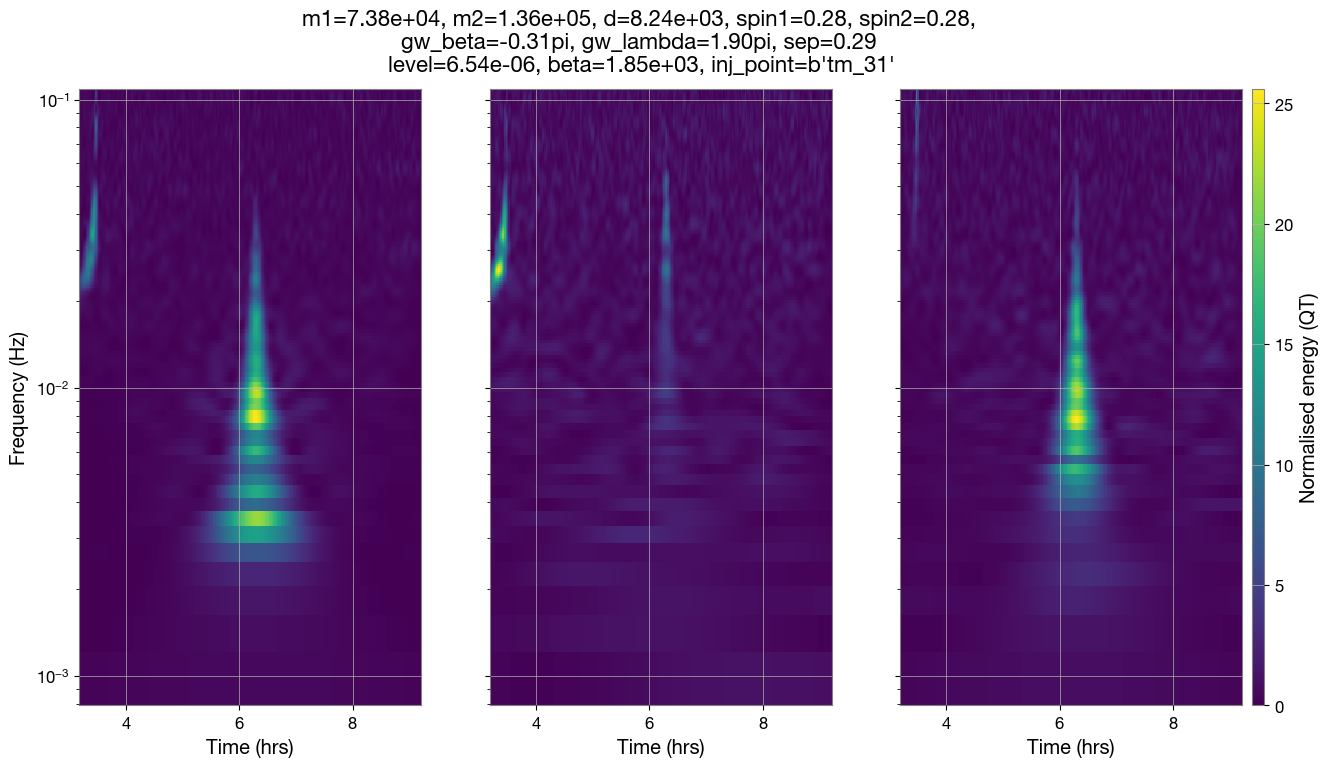

In [48]:
index = 242  # Change this index to visualize different samples

m1 = m1_array[index]
m2 = m2_array[index]
d = d_array[index]
spin1 = spin1_array[index]
spin2 = spin2_array[index]
gw_beta = gw_beta_array[index]
gw_lambda = gw_lambda_array[index]
level = level_array[index]
beta = beta_array[index]
inj_point = inj_point_array[index]
sep = sep_array[index]
QT = qt_array[index]
t_qscan = t_qscan_array[index]
f_qscan = f_qscan_array[index]

QT_A = QT[:, :, 0]
QT_E = QT[:, :, 1]
QT_T = QT[:, :, 2]

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15,8))
title = f'm1={m1:.2e}, m2={m2:.2e}, d={d:.2e}, spin1={spin1:.2f}, spin2={spin2:.2f}, \n' +\
    f'gw_beta={gw_beta/np.pi:.2f}pi, gw_lambda={gw_lambda/np.pi:.2f}pi, sep={sep:.2f} \n'+\
    f'level={level:.2e}, beta={beta:.2e}, inj_point={inj_point}'
fig.suptitle(title, fontsize=16)
    
axes[0].pcolormesh(t_qscan/3600, f_qscan, QT_A, cmap='viridis')
axes[1].pcolormesh(t_qscan/3600, f_qscan, QT_E, cmap='viridis')
axes[2].pcolormesh(t_qscan/3600, f_qscan, QT_T, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[2].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[2].colorbar(label='Normalised energy (QT)')
plt.show()

## Empty

In [11]:
with h5py.File(empty_lm_dataset_path, "r") as h5:
    qt_array = h5["QT"][:]
    t_qscan_array = h5["t_qscan"][:]
    f_qscan_array = h5["f_qscan"][:]

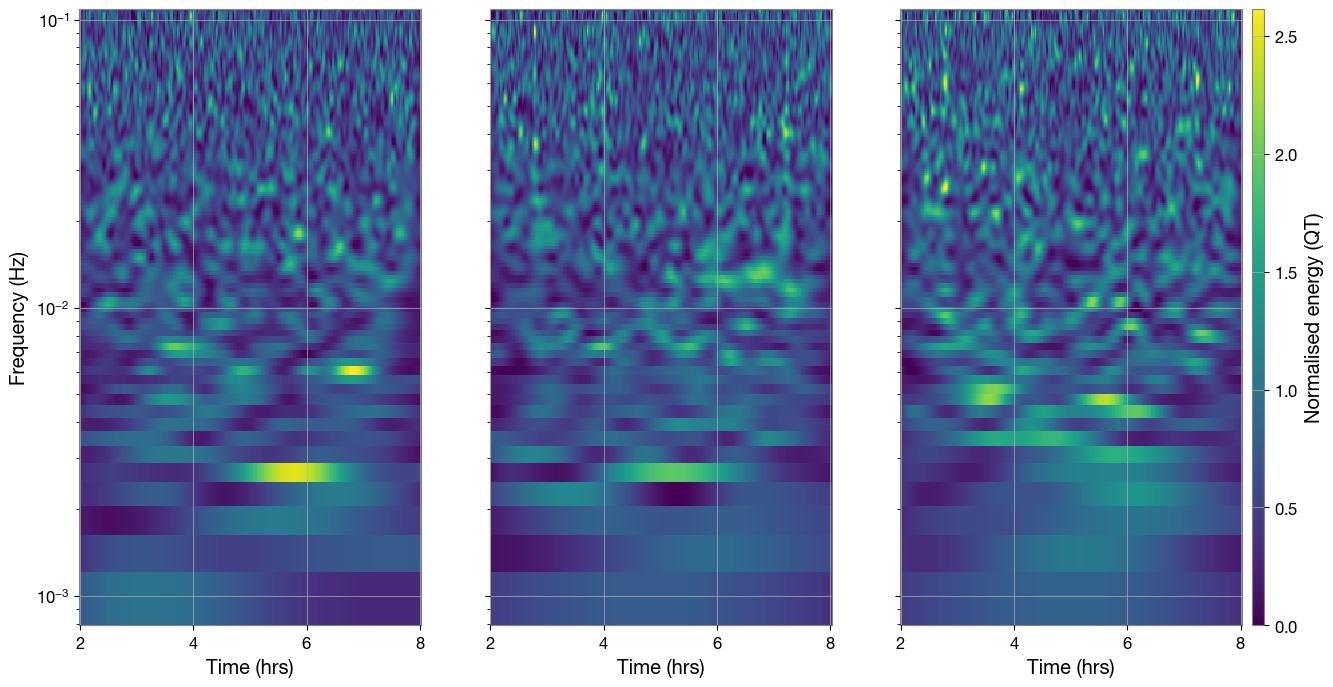

In [12]:
index = 270  # Change this index to visualize different samples
QT = qt_array[index]
t_qscan = t_qscan_array[index]
f_qscan = f_qscan_array[index]

QT_A = QT[:, :, 0]
QT_E = QT[:, :, 1]
QT_T = QT[:, :, 2]

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(15,8))
    
axes[0].pcolormesh(t_qscan/3600, f_qscan, QT_A, cmap='viridis')
axes[1].pcolormesh(t_qscan/3600, f_qscan, QT_E, cmap='viridis')
axes[2].pcolormesh(t_qscan/3600, f_qscan, QT_T, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[2].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[2].colorbar(label='Normalised energy (QT)')
plt.show()